# Solutions to Process 8
Investigate the validity of the proposed $\{PPB, \tau_\alpha\}$ system solved for $\{T_e, n_e\}$.

Try calculating the confinement time without using a scaling law.

In [1]:
# Reload Process each time (keep editable install up-to-date)
%load_ext autoreload
%autoreload 2
from IPython.display import clear_output
import process
from process.main import SingleRun
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from process.io.plot_solutions import (
    RunMetadata,
    plot_mfile_solutions,
    plot_mfile_solutions_constraints,
)

Running scipy's SLSQP


## Set up
Same as in `solutions_to_process_2.ipynb`.

## Calculating the confinement time
Use calculated confinement time rather than scaling: can't solve. fsolve jumps to negative te, ne and get model errors.

Set hfact = 1.0, now no negative te/ne and converges.

In [6]:
w_fracs = np.linspace(5.0e-6, 1.0e-4, 5)
sol_data = {"w": [], "te": [], "ne": [], "tau_e_scaling_hfact": [], "tau_e_calc": []}
for w_frac in w_fracs:
    # Solve Process each time after modifying W fraction
    single_run = SingleRun("lt_tau_alpha_sol_exp_IN.DAT")
    process.fortran.impurity_radiation_module.impurity_arr_frac[13] = w_frac
    try:
        # Handle failed runs
        single_run.run()
    except Exception:
        continue
    sol_data["w"].append(w_frac)
    sol_data["tau_e_scaling_hfact"].append(
        process.fortran.physics_variables.t_energy_confinement_scaling.item()
    )
    sol_data["te"].append(process.fortran.physics_variables.te.item())
    sol_data["ne"].append(process.fortran.physics_variables.dene.item())
    sol_data["tau_e_calc"].append(
        process.fortran.physics_variables.t_energy_confinement.item()
    )

# Clear the lengthy stdout from multiple process runs
clear_output()

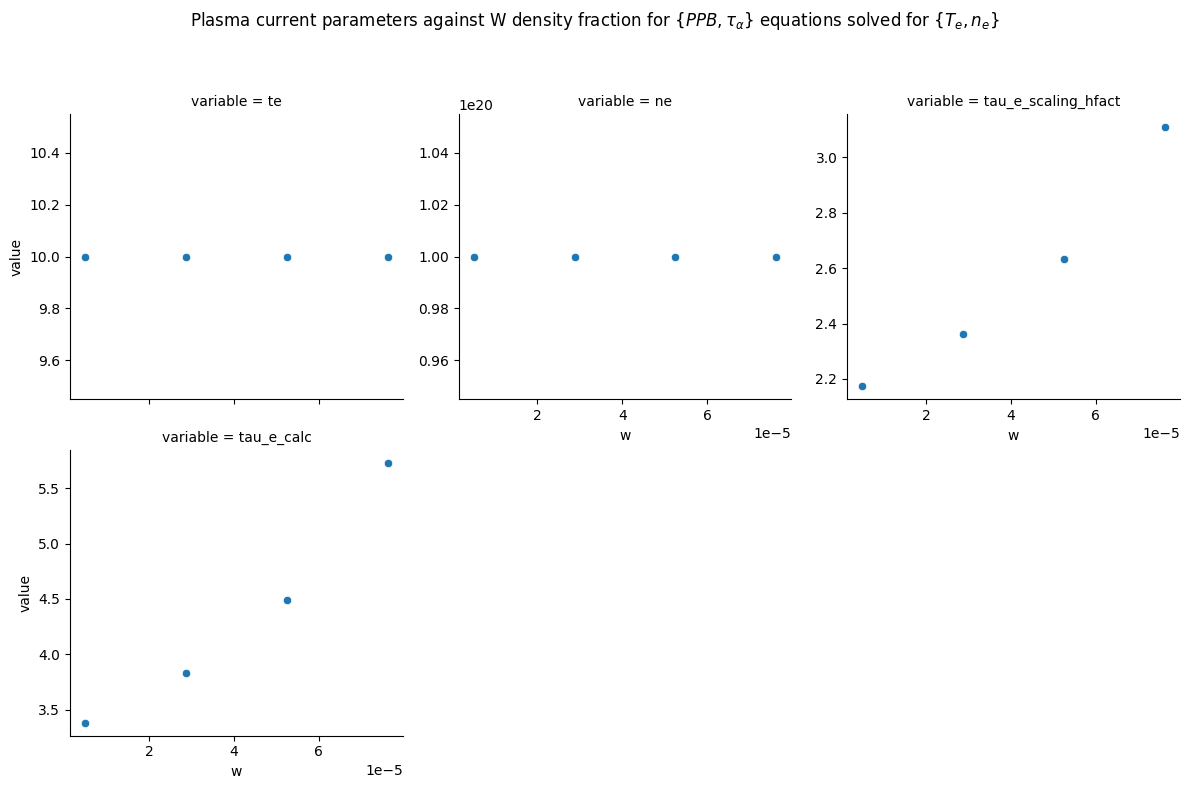

In [8]:
# Plot
sol_df = pd.DataFrame(sol_data)
sol_df_melt = sol_df.melt(id_vars="w")

fg = sns.relplot(
    data=sol_df_melt,
    x="w",
    y="value",
    col="variable",
    col_wrap=3,
    facet_kws=dict(sharey=False),
    height=4,
    aspect=1.0,
)
for axes in fg.axes.flat:
    axes.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))


fg.figure.suptitle(
    r"Plasma current parameters against W density fraction for $\{PPB, \tau_\alpha\}$ equations solved for $\{T_e, n_e\}$"
)
fg.figure.subplots_adjust(top=0.85)

te and ne stay constant: not moving to solve. Constraints satisfied without moving for each W fraction. Calculated and scaling tau_Es very different. Something not right: should be moving to solve.

## Plotting tau_E_calc
Eval runs only: check tau_E_calc varies.

In [ ]:
tes = np.linspace(12.3, 12.7, 5)
sol_data = {"te": [], "ne": [], "tau_e_calc": []}
for te in tes:
    # Evaluate Process each time after modifying W fraction
    single_run = SingleRun("lt_tau_alpha_sol_eval_IN.DAT")
    process.fortran.physics_variables.te = te
    try:
        # Handle failed runs
        single_run.run()
    except Exception:
        continue
    sol_data["te"].append(process.fortran.physics_variables.te.item())
    sol_data["ne"].append(process.fortran.physics_variables.dene.item())
    sol_data["tau_e_calc"].append(
        process.fortran.physics_variables.t_energy_confinement.item()
    )

# Clear the lengthy stdout from multiple process runs
clear_output()

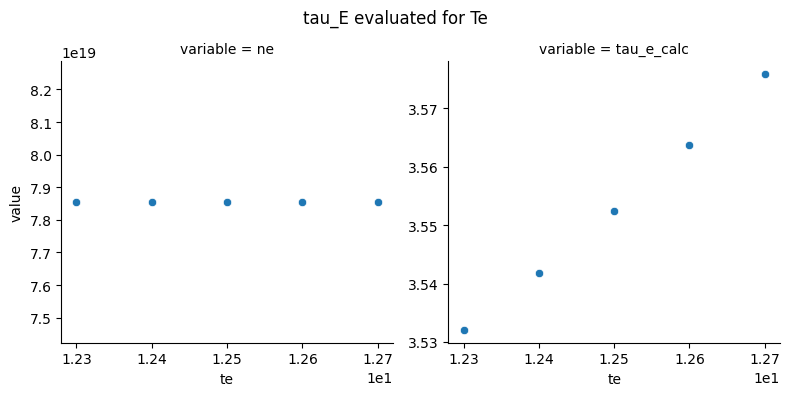

In [10]:
# Plot
sol_df = pd.DataFrame(sol_data)
sol_df_melt = sol_df.melt(id_vars="te")

fg = sns.relplot(
    data=sol_df_melt,
    x="te",
    y="value",
    col="variable",
    col_wrap=2,
    facet_kws=dict(sharey=False),
    height=4,
    aspect=1.0,
)
for axes in fg.axes.flat:
    axes.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))


fg.figure.suptitle(r"tau_E evaluated for Te")
fg.figure.subplots_adjust(top=0.85)

In [11]:
nes = np.linspace(7.5e19, 8.0e19, 5)
sol_data = {"te": [], "ne": [], "tau_e_calc": []}
for ne in nes:
    # Solve Process each time after modifying W fraction
    single_run = SingleRun("lt_tau_alpha_sol_eval_IN.DAT")
    process.fortran.physics_variables.dene = ne
    try:
        # Handle failed runs
        single_run.run()
    except Exception:
        continue
    sol_data["te"].append(process.fortran.physics_variables.te.item())
    sol_data["ne"].append(process.fortran.physics_variables.dene.item())
    sol_data["tau_e_calc"].append(
        process.fortran.physics_variables.t_energy_confinement.item()
    )

# Clear the lengthy stdout from multiple process runs
clear_output()

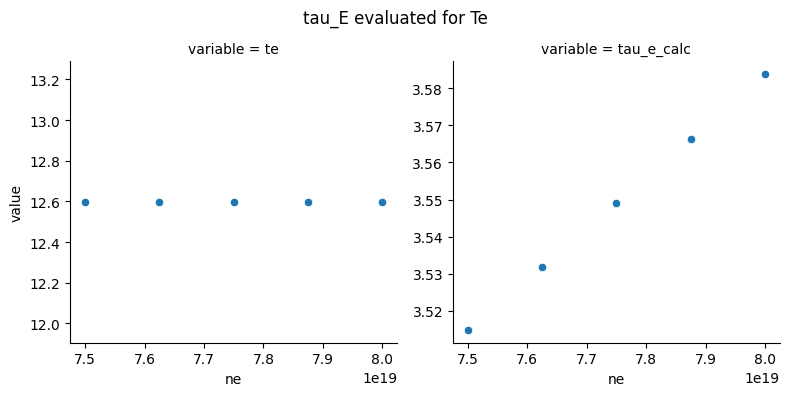

In [12]:
# Plot
sol_df = pd.DataFrame(sol_data)
sol_df_melt = sol_df.melt(id_vars="ne")

fg = sns.relplot(
    data=sol_df_melt,
    x="ne",
    y="value",
    col="variable",
    col_wrap=2,
    facet_kws=dict(sharey=False),
    height=4,
    aspect=1.0,
)
for axes in fg.axes.flat:
    axes.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))


fg.figure.suptitle(r"tau_E evaluated for Te")
fg.figure.subplots_adjust(top=0.85)

tau_E_calc increases with ne and te: it is a function of them. Therefore solver should have reason to vary them to solve PPB.

## Check previous case using scaling tau_E

In [4]:
w_fracs = np.linspace(5.0e-6, 1.0e-4, 5)
sol_data = {"w": [], "te": [], "ne": [], "tau_e_scaling_hfact": [], "tau_e_calc": []}
for w_frac in w_fracs:
    # Solve Process each time after modifying W fraction
    single_run = SingleRun("lt_tau_alpha_sol_exp_IN.DAT")
    process.fortran.impurity_radiation_module.impurity_arr_frac[13] = w_frac
    try:
        # Handle failed runs
        single_run.run()
    except Exception:
        continue
    sol_data["w"].append(w_frac)
    sol_data["tau_e_scaling_hfact"].append(
        process.fortran.physics_variables.t_energy_confinement_scaling.item()
    )
    sol_data["te"].append(process.fortran.physics_variables.te.item())
    sol_data["ne"].append(process.fortran.physics_variables.dene.item())
    sol_data["tau_e_calc"].append(
        process.fortran.physics_variables.t_energy_confinement.item()
    )

# Clear the lengthy stdout from multiple process runs
clear_output()

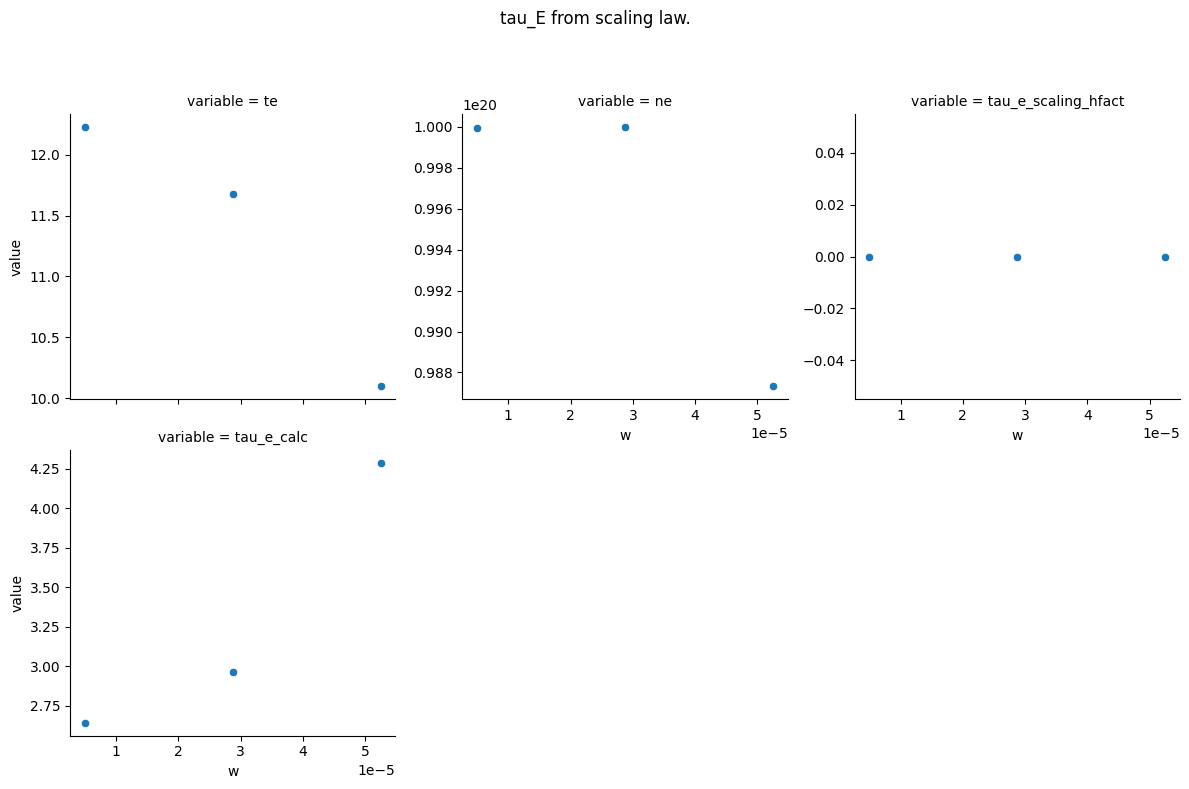

In [6]:
# Plot
sol_df = pd.DataFrame(sol_data)
sol_df_melt = sol_df.melt(id_vars="w")

fg = sns.relplot(
    data=sol_df_melt,
    x="w",
    y="value",
    col="variable",
    col_wrap=3,
    facet_kws=dict(sharey=False),
    height=4,
    aspect=1.0,
)
for axes in fg.axes.flat:
    axes.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))


fg.figure.suptitle(r"tau_E from scaling law.")
fg.figure.subplots_adjust(top=0.85)

Required hfact = 1.2 to solve, some still errorred. tau_e_calc is actually scaling law tau_E here. ne and te varying to solve.

## Plot PPB constraint

In [2]:
w_fracs = np.linspace(5.0e-6, 1.0e-4, 20)
sol_data = {
    "w": [],
    # "te": [],
    # "ne": [],
    # "tau_e_scaling_hfact": [],
    "tau_e_calc": [],
    "ppb_calc": [],
}
for w_frac in w_fracs:
    # Solve Process each time after modifying W fraction
    single_run = SingleRun("lt_tau_alpha_sol_eval_IN.DAT")
    process.fortran.impurity_radiation_module.impurity_arr_frac[13] = w_frac
    try:
        # Handle failed runs
        single_run.run()
    except Exception:
        continue
    sol_data["w"].append(w_frac)
    # sol_data["tau_e_scaling_hfact"].append(
    #     process.fortran.physics_variables.t_energy_confinement_scaling.item()
    # )
    # sol_data["te"].append(process.fortran.physics_variables.te.item())
    # sol_data["ne"].append(process.fortran.physics_variables.dene.item())
    sol_data["tau_e_calc"].append(
        process.fortran.physics_variables.t_energy_confinement.item()
    )
    con2_value, _, _, _, _ = process.fortran.constraints.constraint_eqn_002()
    sol_data["ppb_calc"].append(con2_value)

# Clear the lengthy stdout from multiple process runs
clear_output()

In [5]:
# Plot
tau_e_calc_df = pd.DataFrame(sol_data)
tau_e_calc_df.to_csv("tau_e_calc.csv")
tau_e_calc_df

,w,tau_e_calc,ppb_calc
0,0.000005,3.380741,3.325440e-11
1,0.000010,3.462834,4.803169e-11
2,0.000015,3.550434,6.900536e-11
3,0.000020,3.644239,9.855783e-11
4,0.000025,3.745089,1.397310e-10
5,0.000030,3.854006,1.960876e-10
6,0.000035,3.972248,2.712135e-10
7,0.000040,4.101398,3.677386e-10
8,0.000045,4.243482,-4.479728e-11
9,0.000050,4.401154,-5.943335e-11


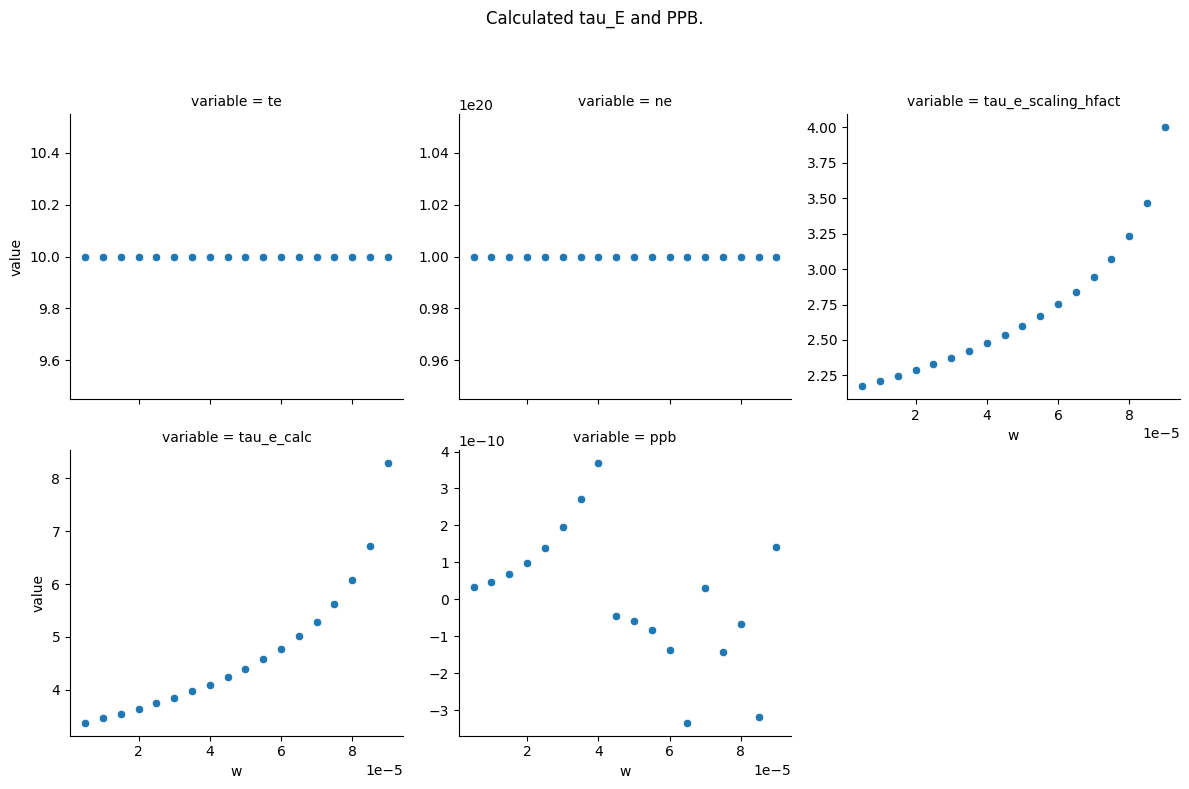

In [4]:
# Plot
sol_df = pd.DataFrame(sol_data)
sol_df_melt = sol_df.melt(id_vars="w")

fg = sns.relplot(
    data=sol_df_melt,
    x="w",
    y="value",
    col="variable",
    col_wrap=3,
    facet_kws=dict(sharey=False),
    height=4,
    aspect=1.0,
)
for axes in fg.axes.flat:
    axes.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))


fg.figure.suptitle(r"Calculated tau_E and PPB.")
fg.figure.subplots_adjust(top=0.85)

And from the scaling law:

In [2]:
w_fracs = np.linspace(5.0e-6, 1.0e-4, 20)
sol_data = {
    "w": [],
    # "te": [],
    # "ne": [],
    # "tau_e_scaling_hfact": [],
    "tau_e_scaling": [],
    "ppb_scaling": [],
}
for w_frac in w_fracs:
    # Solve Process each time after modifying W fraction
    single_run = SingleRun("lt_tau_alpha_sol_eval_IN.DAT")
    process.fortran.impurity_radiation_module.impurity_arr_frac[13] = w_frac
    try:
        # Handle failed runs
        single_run.run()
    except Exception:
        continue
    sol_data["w"].append(w_frac)
    # sol_data["tau_e_scaling_hfact"].append(
    #     process.fortran.physics_variables.t_energy_confinement_scaling.item()
    # )
    # sol_data["te"].append(process.fortran.physics_variables.te.item())
    # sol_data["ne"].append(process.fortran.physics_variables.dene.item())
    sol_data["tau_e_scaling"].append(
        process.fortran.physics_variables.t_energy_confinement.item()
    )
    con2_value, _, _, _, _ = process.fortran.constraints.constraint_eqn_002()
    sol_data["ppb_scaling"].append(con2_value)

# Clear the lengthy stdout from multiple process runs
clear_output()

In [5]:
# Plot
tau_e_scaling_df = pd.DataFrame(sol_data)
tau_e_scaling_df.to_csv("tau_e_scaling.csv")
# sol_df_2_melt = sol_df_2.melt(id_vars="w")

# fg = sns.relplot(
#     data=sol_df_2_melt,
#     x="w",
#     y="value",
#     col="variable",
#     col_wrap=3,
#     facet_kws=dict(sharey=False),
#     height=4,
#     aspect=1.0,
# )
# for axes in fg.axes.flat:
#     axes.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))


# fg.figure.suptitle(r"Scaling law tau_E and PPB.")
# fg.figure.subplots_adjust(top=0.85)

Put data together in single plot.

In [ ]:
# Plot
tau_e_scaling_df = pd.read_csv("tau_e_scaling.csv", index_col=[0])
tau_e_calc_df = pd.read_csv("tau_e_calc.csv", index_col=[0])
sol_df_comb = pd.concat(
    (tau_e_calc_df, tau_e_scaling_df[["tau_e_scaling", "ppb_scaling"]]), axis=1
)
sol_df_comb

,w,tau_e_calc,ppb_calc,tau_e_scaling,ppb_scaling
0,0.000005,3.380741,3.325440e-11,2.942394,-0.066385
1,0.000010,3.462834,4.803169e-11,2.984388,-0.069182
2,0.000015,3.550434,6.900536e-11,3.028172,-0.071956
3,0.000020,3.644239,9.855783e-11,3.073885,-0.074707
4,0.000025,3.745089,1.397310e-10,3.121685,-0.077433
5,0.000030,3.854006,1.960876e-10,3.171748,-0.080134
6,0.000035,3.972248,2.712135e-10,3.224274,-0.082807
7,0.000040,4.101398,3.677386e-10,3.279488,-0.085453
8,0.000045,4.243482,-4.479728e-11,3.337651,-0.088070
9,0.000050,4.401154,-5.943335e-11,3.399060,-0.090655


In [17]:
# Calculate H-factor
sol_df_comb["hfact"] = sol_df_comb["tau_e_calc"] / sol_df_comb["tau_e_scaling"]

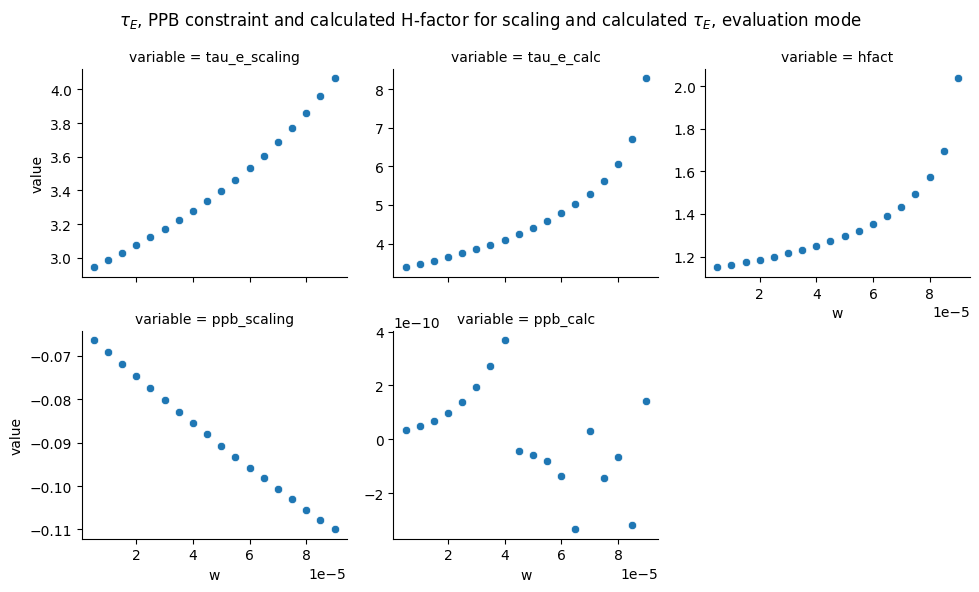

In [22]:
sol_df_comb_melt = sol_df_comb[
    ["w", "tau_e_scaling", "tau_e_calc", "hfact", "ppb_scaling", "ppb_calc"]
].melt(id_vars="w")

fg = sns.relplot(
    data=sol_df_comb_melt,
    x="w",
    y="value",
    col="variable",
    col_wrap=3,
    facet_kws=dict(sharey=False),
    height=3,
    aspect=1.1,
)
for axes in fg.axes.flat:
    axes.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))


fg.figure.suptitle(
    r"$\tau_E$, PPB constraint and calculated H-factor for scaling and calculated $\tau_E$, evaluation mode"
)
fg.figure.subplots_adjust(top=0.88)

## pinj scan

In [10]:
pinjs = np.linspace(50.0, 200.0, 20)
sol_data = {
    "pinj": [],
    "te": [],
    "ne": [],
    "tau_e_scaling_hfact": [],
    "tau_e_calc": [],
    "ppb": [],
}
for pinj in pinjs:
    # Solve Process each time after modifying W fraction
    single_run = SingleRun("lt_tau_alpha_sol_exp_IN.DAT")
    process.fortran.current_drive_variables.p_hcd_primary_extra_heat_mw = pinj
    try:
        # Handle failed runs
        single_run.run()
    except Exception:
        continue
    sol_data["pinj"].append(pinj)
    sol_data["tau_e_scaling_hfact"].append(
        process.fortran.physics_variables.t_energy_confinement_scaling.item()
    )
    sol_data["te"].append(process.fortran.physics_variables.te.item())
    sol_data["ne"].append(process.fortran.physics_variables.dene.item())
    sol_data["tau_e_calc"].append(
        process.fortran.physics_variables.t_energy_confinement.item()
    )
    con2_value, _, _, _, _ = process.fortran.constraints.constraint_eqn_002()
    sol_data["ppb"].append(con2_value)

# Clear the lengthy stdout from multiple process runs
clear_output()

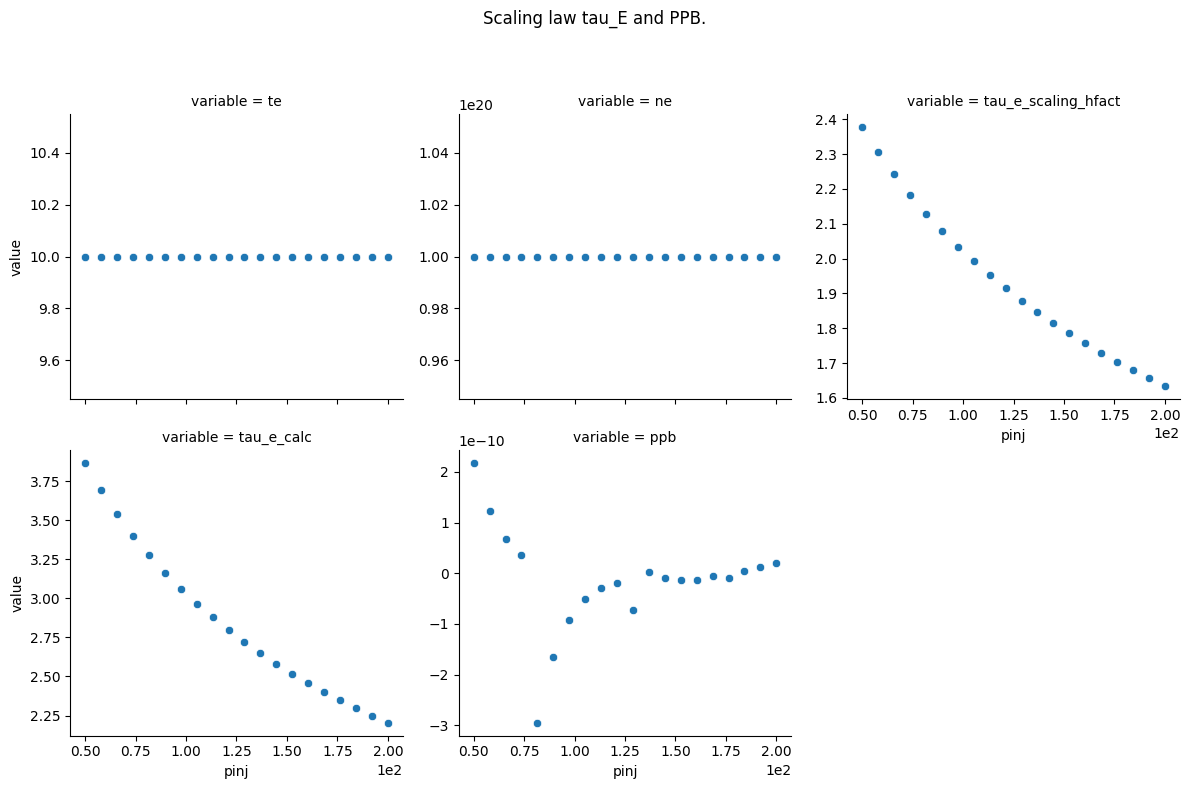

In [11]:
# Plot
sol_df = pd.DataFrame(sol_data)
sol_df_melt = sol_df.melt(id_vars="pinj")

fg = sns.relplot(
    data=sol_df_melt,
    x="pinj",
    y="value",
    col="variable",
    col_wrap=3,
    facet_kws=dict(sharey=False),
    height=4,
    aspect=1.0,
)
for axes in fg.axes.flat:
    axes.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))


fg.figure.suptitle(r"Scaling law tau_E and PPB.")
fg.figure.subplots_adjust(top=0.85)